In [12]:
#let's see how the data is distributed
#import what should be imported
import pandas as pd
import matplotlib.pyplot as plt
import numpy


In [13]:
#the distribution of comments over time
df=pd.read_csv("df_comments_final_v2.csv")
#correcting column name for understandability
df.rename(columns={'published_at':"comment_published_at"}, inplace=True)

In [14]:
df.info()
#lets clean this df a bit

print(len(df.iloc[:,0].unique()))
print(len(df.iloc[:,1].unique()))

#because there are a lots of uniques column 1 and columns 2 will be deleted
df_clean=df.drop([df.columns[col] for col in range(0,2)], axis=1)

df_clean.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10818 entries, 0 to 10817
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            10818 non-null  int64 
 1   author                10813 non-null  object
 2   comment               10813 non-null  object
 3   likes                 10818 non-null  int64 
 4   comment_published_at  10818 non-null  object
 5   video_title           10818 non-null  object
 6   video_published_at    10818 non-null  object
 7   video_url             10818 non-null  object
dtypes: int64(2), object(6)
memory usage: 676.3+ KB
10818
9527


,comment,likes,comment_published_at,video_title,video_published_at,video_url
0,"Love the comments about the mirrors, a bit pat...",0,2025-10-17T05:04:37Z,Tesla Model Y Review 6 Months Later - A BIG RE...,2023-09-12T13:14:40Z,https://www.youtube.com/watch?v=aYmdZWwr7gs
1,First person who actually gave an most accurat...,0,2025-10-14T13:22:08Z,Tesla Model Y Review 6 Months Later - A BIG RE...,2023-09-12T13:14:40Z,https://www.youtube.com/watch?v=aYmdZWwr7gs
2,Getting either a model 3 or Y for work. First ...,0,2025-10-08T14:36:58Z,Tesla Model Y Review 6 Months Later - A BIG RE...,2023-09-12T13:14:40Z,https://www.youtube.com/watch?v=aYmdZWwr7gs
3,Inputted?,0,2025-09-11T03:42:38Z,Tesla Model Y Review 6 Months Later - A BIG RE...,2023-09-12T13:14:40Z,https://www.youtube.com/watch?v=aYmdZWwr7gs
4,BTC/USD 😂,0,2025-08-11T20:17:09Z,Tesla Model Y Review 6 Months Later - A BIG RE...,2023-09-12T13:14:40Z,https://www.youtube.com/watch?v=aYmdZWwr7gs


In [15]:
from datetime import timezone
from dateutil import tz

et=tz.gettz("US/Eastern")
#create data format out of the 2 columns containing "comment"
df_clean['comment_published_at']=pd.to_datetime(df_clean['comment_published_at'])
df_clean['video_published_at']=pd.to_datetime(df_clean['video_published_at'])

#convert time to ET in order to match Nasdaq
df_clean['comment_published_at']=df_clean['comment_published_at'].dt.tz_convert(et)
df_clean['video_published_at']=df_clean['video_published_at'].dt.tz_convert(et)

In [5]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10818 entries, 0 to 10817
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype                                     
---  ------                --------------  -----                                     
 0   comment               10813 non-null  str                                       
 1   likes                 10818 non-null  int64                                     
 2   comment_published_at  10818 non-null  datetime64[us, tzfile('America/New_York')]
 3   video_title           10818 non-null  str                                       
 4   video_published_at    10818 non-null  datetime64[us, tzfile('America/New_York')]
 5   video_url             10818 non-null  str                                       
dtypes: datetime64[us, tzfile('America/New_York')](2), int64(1), str(3)
memory usage: 3.0 MB


In [16]:
df_clean['month-year']=df_clean['comment_published_at'].dt.strftime("%B-%Y")

df_clean.sort_values('comment_published_at', inplace=True)

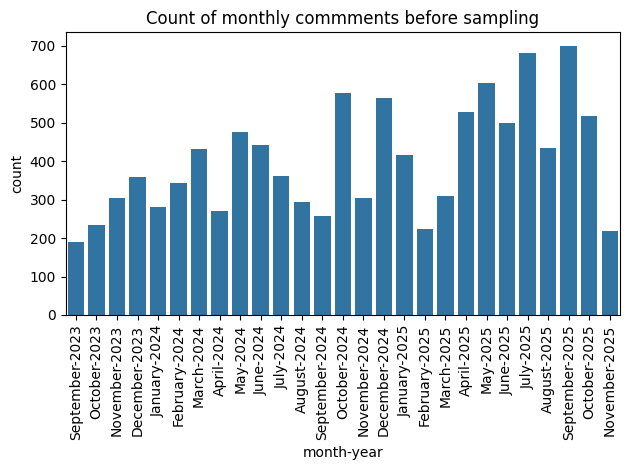

In [7]:
import seaborn as sns

sns.countplot(x='month-year', data=df_clean)
plt.xticks(rotation=90)
plt.title("Count of monthly commments before sampling")
plt.tight_layout()
plt.savefig("Count before.png",transparent=True)
plt.show()

In [17]:
df_clean['month-year'].value_counts()

month-year
September-2025    700
July-2025         681
May-2025          604
October-2024      576
December-2024     565
April-2025        527
October-2025      517
June-2025         499
May-2024          475
June-2024         441
August-2025       433
March-2024        432
January-2025      417
July-2024         362
December-2023     360
February-2024     343
March-2025        310
November-2024     305
November-2023     304
August-2024       293
January-2024      280
April-2024        271
September-2024    257
October-2023      234
February-2025     223
November-2025     219
September-2023    190
Name: count, dtype: int64

In [18]:
#random sampling comments for each month-year
#n=100

df_sampled=df_clean.groupby("month-year").sample(n=150, random_state=104)
df_sampled['month-year'].value_counts()

month-year
April-2024        150
March-2024        150
September-2024    150
September-2023    150
October-2025      150
October-2024      150
October-2023      150
November-2025     150
November-2024     150
November-2023     150
May-2025          150
May-2024          150
March-2025        150
June-2025         150
April-2025        150
June-2024         150
July-2025         150
July-2024         150
January-2025      150
January-2024      150
February-2025     150
February-2024     150
December-2024     150
December-2023     150
August-2025       150
August-2024       150
September-2025    150
Name: count, dtype: int64

In [10]:
#checking for na values or non string one in comment
print(df_sampled.info())
#nice we have got 2 N/A values that destoy everything
df_sampled.isna().sum()

<class 'pandas.DataFrame'>
Index: 4050 entries, 1281 to 4418
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype                                     
---  ------                --------------  -----                                     
 0   comment               4050 non-null   str                                       
 1   likes                 4050 non-null   int64                                     
 2   comment_published_at  4050 non-null   datetime64[us, tzfile('America/New_York')]
 3   video_title           4050 non-null   str                                       
 4   video_published_at    4050 non-null   datetime64[us, tzfile('America/New_York')]
 5   video_url             4050 non-null   str                                       
 6   month-year            4050 non-null   str                                       
dtypes: datetime64[us, tzfile('America/New_York')](2), int64(1), str(4)
memory usage: 1.3 MB
None


comment                 0
likes                   0
comment_published_at    0
video_title             0
video_published_at      0
video_url               0
month-year              0
dtype: int64

In [22]:
for column in df_sampled.columns:
    print(f"Descriptive statistics: for column {column} \n {df_sampled[column].describe()} \n")

Descriptive statistics: for column comment 
 count     4050
unique    4019
top          1
freq         8
Name: comment, dtype: object 

Descriptive statistics: for column likes 
 count    4050.000000
mean        1.960988
std        30.919848
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max      1723.000000
Name: likes, dtype: float64 

Descriptive statistics: for column comment_published_at 
 count                                   4050
mean     2024-10-14 23:12:23.989135872-04:00
min                2023-09-07 06:13:53-04:00
25%      2024-03-07 16:23:39.750000128-05:00
50%                2024-10-14 19:20:31-04:00
75%      2025-05-06 16:24:57.750000128-04:00
max                2025-11-17 08:30:44-05:00
Name: comment_published_at, dtype: object 

Descriptive statistics: for column video_title 
 count                                                  4050
unique                                                   75
top       NEW Tesla Model 3 facelift 

Creating the Sentiment analysis for each comment

In [11]:
!python -c "import torch; print(torch.__version__)"

2.10.0+cu128


In [12]:
!python -c "import transformers; print(transformers.__version__)"


5.3.0


In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from langdetect import detect

#declaring models for english
tokenizer_en=AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest", trust_remote_code=True)
model_en = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest", trust_remote_code=True)

# Multilingual model (XLM-RoBERTa)
tokenizer_multi = AutoTokenizer.from_pretrained("cardiffnlp/twitter-xlm-roberta-base-sentiment", trust_remote_code=True)
model_multi = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-xlm-roberta-base-sentiment", trust_remote_code=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_en.to(device)
model_multi.to(device)


#first function for detecting language
def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unkown"
    
#creating label map:
label_map={0:'negative', 1:'neutral', 2:'positive'}
#second function for getting sentiment

def get_sentiment(lang,text):
    if lang=='en':
        tokenizer=tokenizer_en
        model=model_en
    else:
        tokenizer=tokenizer_multi
        model=model_multi
    tokenized_text=tokenizer(text, return_tensors='pt', padding="max_length", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs=model(**tokenized_text)
        logits=outputs.logits
        probs=torch.softmax(logits, dim=-1)
    
    predicted_class=torch.argmax(probs, dim=-1).item() #item() returns the poition in the array
    confidence=probs[0][predicted_class].item()

    return{
        "label":label_map[predicted_class],
        'probabilities':probs.tolist()

    }




    



/home/jovyan/.conda-envs/Marc_Qwen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 20877.00it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11915.13it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key            

In [14]:
text="Right, so I've owned the Tesla Model Y for about six months now and I was going to do a review straight away but I thought that's not going to be very helpful for you because how can you properly get to know a car inside out in that short amount of time? You need to really get to know all of the little features and details, pros and cons, all the quirks, especially when jumping from a petrol or diesel engine which I've previously owned. Things you can only really know after a good few miles. So here we are, six months in. What's it really been like to drive? In terms of comfort and enjoyment, the software and infotainment system, app usage and connectivity subscription, hardware and build quality, charging including home and public options and the dreaded range anxiety that you'll only truly know "
result=get_sentiment(detect_lang(text), text)

In [15]:
print("Outputs \n ", result['probabilities'])
print("Label \n, ", result['label'])
tensor=result['probabilities']

type(tensor)
print(type(tensor[0]))
tensor[0][0]

Outputs 
  [[0.31408968567848206, 0.5928544998168945, 0.09305578470230103]]
Label 
,  neutral
<class 'list'>


0.31408968567848206

In [16]:
#trying it out on an example string
str='I love tesla👍 youhooo'
print(get_sentiment(detect_lang(str), str))

{'label': 'positive', 'probabilities': [[0.0028770752251148224, 0.009091201238334179, 0.9880317449569702]]}


In [ ]:
#saving list of probabilities to sentiment column negative, neutral, positive
df_sampled["lang"] = df_sampled["comment"].apply(detect_lang)
df_sampled["sentiment"] = df_sampled.apply(lambda row: get_sentiment(row["lang"], row["comment"])['probabilities'][0], axis=1)


In [19]:
#unpacking array and creating iverall sentiment with the following formula positive-negative -> [-1,1]
df_sampled['comment_sentiment']=df_sampled['sentiment'].apply(lambda x: x[2]-x[0])

In [21]:
#save the dataframe
df_sampled.drop('sentiment', inplace=True, axis=1)
df_sampled.to_csv("df_sampled_sentiment.csv")